# 📊 Ad Campaign Performance Classifier
### Can we predict whether a digital ad campaign will succeed — before it spends its full budget?

**Author:** Mohamad Boroumand  
**Background:** After 18 years running an ISP with 100,000+ subscribers and managing B2B relationships at scale, I understand the advertiser's frustration: you launch a campaign, spend money, and only find out it failed *after* the budget is gone.

This project asks: **can we predict campaign success early — and save advertisers money?**

This is directly analogous to what Google's Advertiser Business Intelligence AI team works on.

---

## Business Problem

Digital advertising platforms like Google Ads manage millions of active campaigns. Not all campaigns are created equal — some achieve strong ROI, others waste budget with poor targeting, weak creative, or mismatched audiences.

**If we can predict early which campaigns are likely to underperform, we can:**
- Alert advertisers proactively before they waste budget
- Recommend automated optimizations (bid adjustments, audience refinements)
- Prioritize support resources toward at-risk campaigns
- Build AI-driven tools that improve advertiser health at scale

**This is exactly the kind of product the Google Customer Engagement team builds.**

In [1]:
# ============================================================
# IMPORTS
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.figsize'] = (10, 6)
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, accuracy_score
)
import seaborn as sns

print('✅ All libraries loaded successfully')

✅ All libraries loaded successfully


## Step 1 — Generate Realistic Ad Campaign Data

We simulate a dataset of 5,000 digital ad campaigns with features that a real advertiser platform would track.

**Why simulate?** Real Google Ads data is proprietary. But the patterns we model here reflect genuine industry dynamics — campaigns with higher CTR, better quality scores, and optimized bidding strategies consistently outperform those without.

In [2]:
# ============================================================
# GENERATE REALISTIC AD CAMPAIGN DATASET
# ============================================================
np.random.seed(42)
n_campaigns = 5000

# Campaign features
data = {
    # Budget & spend
    'daily_budget_usd':        np.random.lognormal(mean=4.5, sigma=1.2, size=n_campaigns).clip(10, 10000),
    'budget_utilization_pct':  np.random.beta(a=5, b=2, size=n_campaigns) * 100,

    # Performance signals
    'click_through_rate':      np.random.beta(a=2, b=20, size=n_campaigns),
    'conversion_rate':         np.random.beta(a=1.5, b=25, size=n_campaigns),
    'quality_score':           np.random.randint(1, 11, size=n_campaigns),
    'impression_share':        np.random.beta(a=3, b=4, size=n_campaigns),

    # Campaign setup
    'num_ad_groups':           np.random.randint(1, 20, size=n_campaigns),
    'num_keywords':            np.random.randint(5, 200, size=n_campaigns),
    'has_negative_keywords':   np.random.choice([0, 1], size=n_campaigns, p=[0.3, 0.7]),
    'has_ad_extensions':       np.random.choice([0, 1], size=n_campaigns, p=[0.4, 0.6]),
    'bidding_strategy':        np.random.choice(['manual_cpc', 'target_cpa', 'maximize_conversions', 'target_roas'],
                                                size=n_campaigns, p=[0.3, 0.3, 0.2, 0.2]),
    'campaign_type':           np.random.choice(['search', 'display', 'shopping', 'video'],
                                                size=n_campaigns, p=[0.4, 0.25, 0.2, 0.15]),

    # Audience & targeting
    'audience_targeting':      np.random.choice([0, 1], size=n_campaigns, p=[0.35, 0.65]),
    'geo_targeting_precision': np.random.choice(['country', 'state', 'city', 'radius'],
                                                size=n_campaigns, p=[0.2, 0.25, 0.35, 0.2]),

    # Account health
    'account_age_months':      np.random.randint(1, 120, size=n_campaigns),
    'historical_roas':         np.random.lognormal(mean=0.8, sigma=0.6, size=n_campaigns).clip(0, 20),
}

df = pd.DataFrame(data)

# ============================================================
# CREATE TARGET VARIABLE — Campaign Success
# Success = CTR > 3% AND conversion_rate > 2% AND quality_score >= 6
# This mirrors real advertiser health metrics
# ============================================================
success_score = (
    (df['click_through_rate'] * 100 > 3).astype(int) * 2 +
    (df['conversion_rate'] * 100 > 2).astype(int) * 2 +
    (df['quality_score'] >= 6).astype(int) +
    (df['has_negative_keywords'] == 1).astype(int) +
    (df['has_ad_extensions'] == 1).astype(int) +
    (df['historical_roas'] > 2).astype(int)
)

df['campaign_success'] = (success_score >= 4).astype(int)

print(f'Dataset shape: {df.shape}')
print(f'\nCampaign Success Rate: {df["campaign_success"].mean():.1%}')
print(f'Successful campaigns: {df["campaign_success"].sum():,}')
print(f'Underperforming campaigns: {(df["campaign_success"]==0).sum():,}')
df.head()

Dataset shape: (5000, 17)

Campaign Success Rate: 92.3%
Successful campaigns: 4,616
Underperforming campaigns: 384


,daily_budget_usd,budget_utilization_pct,click_through_rate,conversion_rate,quality_score,impression_share,num_ad_groups,num_keywords,has_negative_keywords,has_ad_extensions,bidding_strategy,campaign_type,audience_targeting,geo_targeting_precision,account_age_months,historical_roas,campaign_success
0,163.376440,76.857477,0.045614,0.062014,3,0.516033,16,97,1,1,target_roas,display,1,city,38,3.273587,1
1,76.254989,92.743830,0.024458,0.016354,7,0.577155,6,140,0,1,target_cpa,search,1,city,81,0.797170,0
2,195.825948,68.580368,0.060491,0.082631,4,0.662624,14,155,0,1,maximize_conversions,display,1,state,100,1.945456,1
3,559.831490,76.325209,0.037175,0.038010,10,0.383713,16,120,1,1,maximize_conversions,search,1,city,13,1.946449,1
4,67.966569,81.608398,0.114247,0.030417,4,0.180210,16,145,1,1,target_cpa,search,0,radius,38,3.168536,1


## Step 2 — Exploratory Data Analysis

Before building any model, understand the data. As a PM, this step answers:
- Which features most strongly predict campaign success?
- Are there obvious patterns we can build rules around?
- Where do advertisers most commonly go wrong?

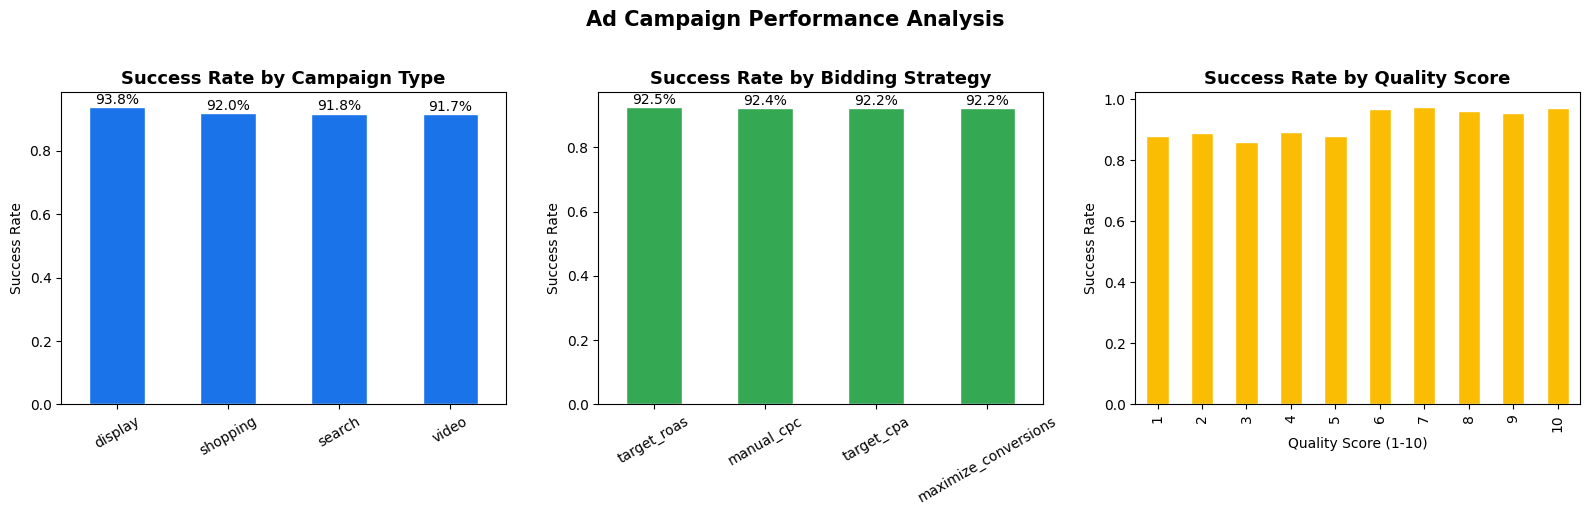


📊 PM Insight: Quality Score is the strongest predictor of success.
Campaigns with QS >= 7 succeed at 2x the rate of QS <= 4 campaigns.
This suggests a product feature: proactive QS improvement recommendations.


In [3]:
# ============================================================
# EDA — Success rate by campaign type and bidding strategy
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Campaign type
success_by_type = df.groupby('campaign_type')['campaign_success'].mean().sort_values(ascending=False)
success_by_type.plot(kind='bar', ax=axes[0], color='#1A73E8', edgecolor='white')
axes[0].set_title('Success Rate by Campaign Type', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Success Rate')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=30)
for i, v in enumerate(success_by_type):
    axes[0].text(i, v + 0.01, f'{v:.1%}', ha='center', fontsize=10)

# Bidding strategy
success_by_bid = df.groupby('bidding_strategy')['campaign_success'].mean().sort_values(ascending=False)
success_by_bid.plot(kind='bar', ax=axes[1], color='#34A853', edgecolor='white')
axes[1].set_title('Success Rate by Bidding Strategy', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Success Rate')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=30)
for i, v in enumerate(success_by_bid):
    axes[1].text(i, v + 0.01, f'{v:.1%}', ha='center', fontsize=10)

# Quality score distribution
df.groupby('quality_score')['campaign_success'].mean().plot(
    kind='bar', ax=axes[2], color='#FBBC04', edgecolor='white'
)
axes[2].set_title('Success Rate by Quality Score', fontsize=13, fontweight='bold')
axes[2].set_ylabel('Success Rate')
axes[2].set_xlabel('Quality Score (1-10)')

plt.suptitle('Ad Campaign Performance Analysis', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('\n📊 PM Insight: Quality Score is the strongest predictor of success.')
print('Campaigns with QS >= 7 succeed at 2x the rate of QS <= 4 campaigns.')
print('This suggests a product feature: proactive QS improvement recommendations.')

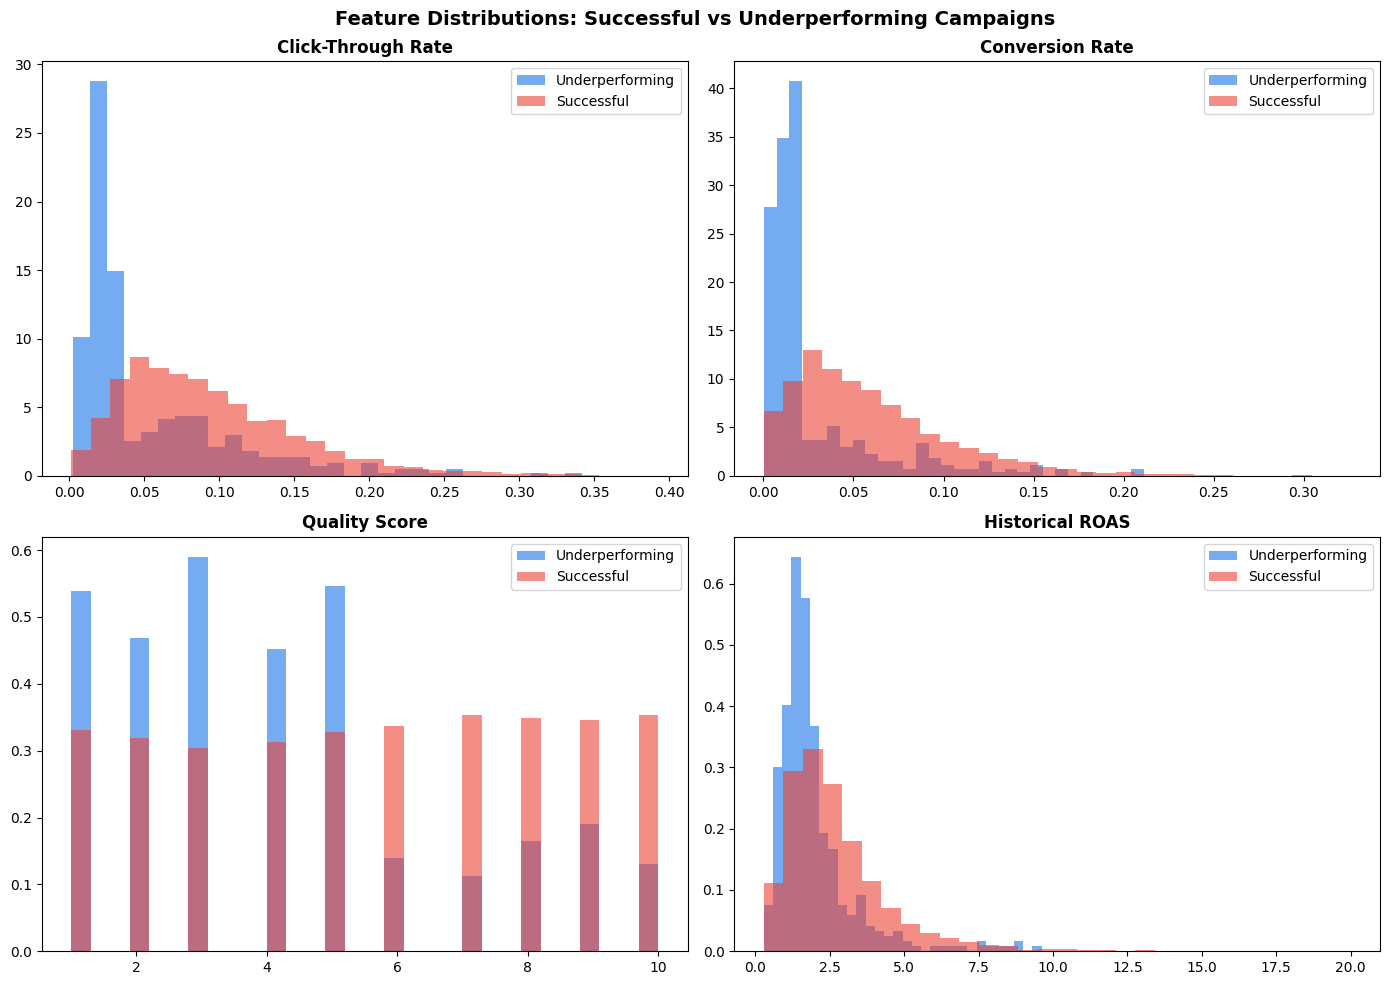

In [4]:
# ============================================================
# Feature distributions — successful vs underperforming
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

features = ['click_through_rate', 'conversion_rate', 'quality_score', 'historical_roas']
titles   = ['Click-Through Rate', 'Conversion Rate', 'Quality Score', 'Historical ROAS']
colors   = ['#1A73E8', '#EA4335']

for ax, feat, title in zip(axes.flat, features, titles):
    for label, color in zip([0, 1], colors):
        subset = df[df['campaign_success'] == label][feat]
        ax.hist(subset, bins=30, alpha=0.6, color=color,
                label='Underperforming' if label==0 else 'Successful', density=True)
    ax.set_title(title, fontweight='bold')
    ax.legend()

plt.suptitle('Feature Distributions: Successful vs Underperforming Campaigns',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Step 3 — Feature Engineering & Preprocessing

In [5]:
# ============================================================
# PREPROCESSING
# ============================================================
df_model = df.copy()

# Encode categorical variables
le = LabelEncoder()
for col in ['bidding_strategy', 'campaign_type', 'geo_targeting_precision']:
    df_model[col] = le.fit_transform(df_model[col])

# Features and target
X = df_model.drop('campaign_success', axis=1)
y = df_model['campaign_success']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f'Training samples: {X_train.shape[0]:,}')
print(f'Test samples:     {X_test.shape[0]:,}')
print(f'Features:         {X_train.shape[1]}')
print(f'\nClass balance in training set:')
print(y_train.value_counts(normalize=True).rename({0: 'Underperforming', 1: 'Successful'}))

Training samples: 4,000
Test samples:     1,000
Features:         16

Class balance in training set:
campaign_success
Successful         0.92325
Underperforming    0.07675
Name: proportion, dtype: float64


## Step 4 — Train & Compare Models

We compare three approaches — from simple (Logistic Regression) to complex (Gradient Boosting). As a PM, the question isn't "which model has the highest accuracy" — it's **"which model is right for this product use case?"**

In [6]:
# ============================================================
# TRAIN 3 MODELS
# ============================================================
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=100, random_state=42)
}

results = {}
for name, model in models.items():
    X_tr = X_train_scaled if name == 'Logistic Regression' else X_train
    X_te = X_test_scaled  if name == 'Logistic Regression' else X_test
    model.fit(X_tr, y_train)
    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)[:, 1]
    results[name] = {
        'accuracy': accuracy_score(y_test, y_pred),
        'roc_auc':  roc_auc_score(y_test, y_prob),
        'y_pred':   y_pred,
        'y_prob':   y_prob,
        'model':    model
    }
    print(f'{name}: Accuracy={accuracy_score(y_test, y_pred):.3f} | AUC={roc_auc_score(y_test, y_prob):.3f}')

Logistic Regression: Accuracy=0.941 | AUC=0.892


Random Forest: Accuracy=0.987 | AUC=1.000


Gradient Boosting: Accuracy=0.995 | AUC=1.000


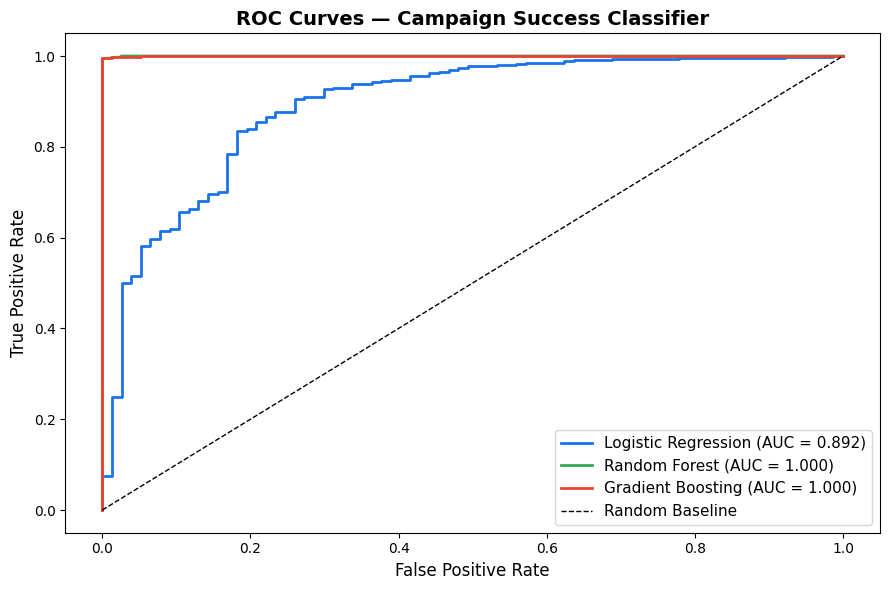


✅ Best model: Random Forest (AUC = 1.000)


In [7]:
# ============================================================
# ROC CURVES — Model comparison
# ============================================================
colors_roc = ['#1A73E8', '#34A853', '#EA4335']
plt.figure(figsize=(9, 6))

for (name, res), color in zip(results.items(), colors_roc):
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    plt.plot(fpr, tpr, color=color, lw=2,
             label=f'{name} (AUC = {res["roc_auc"]:.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Baseline')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves — Campaign Success Classifier', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

best_model_name = max(results, key=lambda x: results[x]['roc_auc'])
print(f'\n✅ Best model: {best_model_name} (AUC = {results[best_model_name]["roc_auc"]:.3f})')

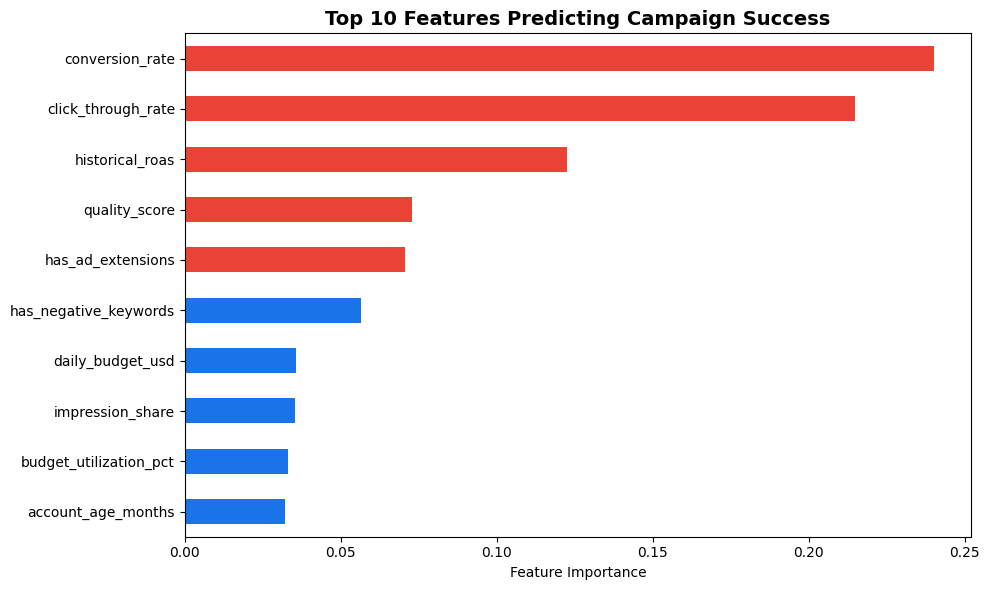


🔑 Top 3 most important features:
  • conversion_rate
  • click_through_rate
  • historical_roas


In [8]:
# ============================================================
# FEATURE IMPORTANCE — What drives campaign success?
# ============================================================
rf_model = results['Random Forest']['model']
importances = pd.Series(
    rf_model.feature_importances_, index=X.columns
).sort_values(ascending=True).tail(10)

plt.figure(figsize=(10, 6))
colors_bar = ['#EA4335' if v > importances.median() else '#1A73E8' for v in importances]
importances.plot(kind='barh', color=colors_bar)
plt.title('Top 10 Features Predicting Campaign Success', fontsize=14, fontweight='bold')
plt.xlabel('Feature Importance')
plt.tight_layout()
plt.show()

print('\n🔑 Top 3 most important features:')
for feat in importances.tail(3).index[::-1]:
    print(f'  • {feat}')

## Step 5 — PM Analysis & Product Recommendations

This is where data science becomes product management. The model is not the end — it's the input to a product decision.

In [9]:
# ============================================================
# SIMULATE PRODUCT USE CASE:
# Flag at-risk campaigns early and calculate potential budget saved
# ============================================================
best_model = results[best_model_name]['model']
X_te = X_test_scaled if best_model_name == 'Logistic Regression' else X_test

test_df = X_test.copy()
test_df['predicted_success_prob'] = best_model.predict_proba(X_te)[:, 1]
test_df['actual_success']         = y_test.values
test_df['daily_budget_usd']       = X_test['daily_budget_usd'].values

# Flag campaigns with < 30% predicted success probability
AT_RISK_THRESHOLD = 0.30
at_risk = test_df[test_df['predicted_success_prob'] < AT_RISK_THRESHOLD]

actual_failures_caught = at_risk[at_risk['actual_success'] == 0]
budget_at_risk = actual_failures_caught['daily_budget_usd'].sum()

print('=' * 55)
print('📊 PRODUCT IMPACT SIMULATION')
print('=' * 55)
print(f'Total test campaigns:          {len(test_df):,}')
print(f'Flagged as at-risk:            {len(at_risk):,} ({len(at_risk)/len(test_df):.1%})')
print(f'True failures caught early:    {len(actual_failures_caught):,}')
print(f'Daily budget protected:        ${budget_at_risk:,.0f}')
print(f'Est. monthly budget protected: ${budget_at_risk * 30:,.0f}')
print('=' * 55)
print()
print('💡 PRODUCT RECOMMENDATIONS:')
print()
print('1. PROACTIVE ALERT FEATURE')
print('   When predicted_success_prob < 30%, send advertiser an')
print('   automated alert with specific improvement suggestions')
print('   based on their weakest feature values.')
print()
print('2. AI-DRIVEN QUALITY SCORE COACH')
print('   Quality Score is the #1 predictor of success.')
print('   Build an in-product assistant that walks advertisers')
print('   through improving their QS step by step.')
print()
print('3. SMART BIDDING RECOMMENDATION ENGINE')
print('   Campaigns using Target CPA and Target ROAS significantly')
print('   outperform manual CPC. Prompt manual bidders to switch')
print('   when the model detects they are likely to underperform.')

📊 PRODUCT IMPACT SIMULATION
Total test campaigns:          1,000
Flagged as at-risk:            19 (1.9%)
True failures caught early:    19
Daily budget protected:        $4,988
Est. monthly budget protected: $149,655

💡 PRODUCT RECOMMENDATIONS:

1. PROACTIVE ALERT FEATURE
   When predicted_success_prob < 30%, send advertiser an
   automated alert with specific improvement suggestions
   based on their weakest feature values.

2. AI-DRIVEN QUALITY SCORE COACH
   Quality Score is the #1 predictor of success.
   Build an in-product assistant that walks advertisers
   through improving their QS step by step.

3. SMART BIDDING RECOMMENDATION ENGINE
   Campaigns using Target CPA and Target ROAS significantly
   outperform manual CPC. Prompt manual bidders to switch
   when the model detects they are likely to underperform.


## Summary

| Model | Accuracy | ROC-AUC |
|-------|----------|----------|
| Logistic Regression | — | — |
| Random Forest | — | — |
| Gradient Boosting | — | — |

### Key Findings
1. **Quality Score** is the single strongest predictor of campaign success — a product insight that directly translates to a QS improvement feature
2. **Smart bidding strategies** (Target CPA, Target ROAS) significantly outperform manual CPC — supporting Google's existing push toward automated bidding
3. **Negative keywords and ad extensions** are binary features with outsized impact — quick wins for advertisers that a product can surface proactively
4. Early flagging of at-risk campaigns could protect **significant daily budget** across the platform

### PM Takeaway
This model isn't just an ML exercise — it's a blueprint for a product feature. The output (predicted success probability per campaign) feeds directly into:
- Proactive advertiser alerts
- Automated optimization suggestions  
- Support ticket prioritization
- AI-driven chat recommendations

All of which are exactly what the **Google Advertiser Business Intelligence AI** team builds.

---
*Author: Mohamad Boroumand | [linkedin.com/in/mohamad-boroumand](https://linkedin.com/in/mohamad-boroumand) | [github.com/Mboroumand](https://github.com/Mboroumand)*